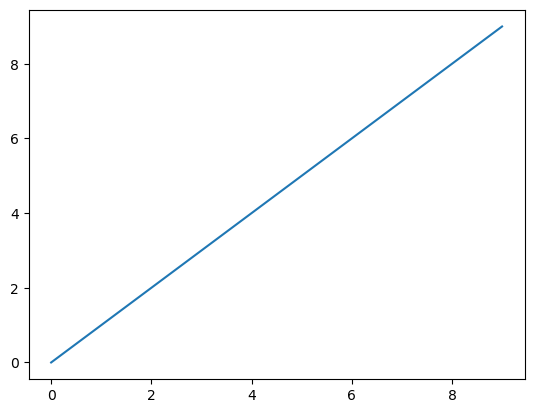

In [13]:
#package imports
#If using Jupyter locally, make sure you have pip installed saphires and any dependencies you need.
import saphires as saph
import matplotlib
import matplotlib.pyplot as plt
#matplotlib.use('Qt5Agg')
%matplotlib inline

import numpy as np
import os
from scipy.optimize import curve_fit

import pickle as pkl
from scipy.ndimage import gaussian_filter
import astropy



x = [0,1,2,3,4,5,6,7,8,9]
y = x
plt.plot(x, y)    #Testing out matplotlib inline to make sure this runs
print()
plt.show()

In [79]:
import os, glob
import numpy as np
from astropy.time import Time

star = 'EZPeg'


folder = os.path.join(r"C:\Users\Jonah\Astro\Stars\DATA\stars2", star)

# 1) find all .p files whose basename starts with the same first letter as `star`
txtfiles = sorted(
    os.path.basename(f)
    for f in glob.glob(os.path.join(folder, "*.p"))
    if os.path.basename(f)[0].lower() == star[0].lower()
)

# 2) load the .dat into a true 2-D object array
dat_path  = os.path.join(folder, f"{star}_nres_head.dat")
#dat_path  = os.path.join(folder, f"{star}_nres_head.dat")
stardata  = np.genfromtxt(dat_path, delimiter=",", dtype=object)

# 3) slice out cols 5 and 6 and convert to float
BJD       = stardata[:, 5].astype(float)
BVCORR    = stardata[:, 6].astype(float)



# OPTIONAL: remove one entry (file + BJD + BVCORR)
#idx_to_remove = 0  # zero-based index of the row you want to drop
#txtfiles.pop(idx_to_remove)
#BJD    = np.delete(BJD,    idx_to_remove)
#BVCORR = np.delete(BVCORR, idx_to_remove)






# 4) convert BJD (TDB) → UTC ISO strings via Astropy
times = Time(BJD, format='jd', scale='tdb')
dates = times.utc.iso  # array of "YYYY-MM-DD HH:MM:SS.sss" strings in UTC

# string/table format for print check
header_fmt = "{:>3}  {:^32}  {:^25}    {:^12}    {:^16}"
row_fmt    = "{:>3}  {:<32}  {:<25}    {:>12}    {:>10}"

# 5) print header
print(header_fmt.format("Idx", "Filename", "Date (UTC)", "BJD", "BVCORR"))
print("-" * 100)

# 6) print each row
for i, (fn, date, bjd, bv) in enumerate(zip(txtfiles, dates, BJD, BVCORR), start=1):
    # truncate milliseconds to three decimal places:
    date_str = date  # already "YYYY-MM-DD HH:MM:SS.sss"
    print(row_fmt.format(i, fn, date_str, f"{bjd:.6f}", f"{bv:.3f}"))


path = os.path.join(folder, "")
print(f"\n{path}")

Idx              Filename                     Date (UTC)                BJD              BVCORR     
----------------------------------------------------------------------------------------------------
  1  EZPeg_2025-07-07_0_6300_4.5.p     2025-07-07 23:59:57.359      2460864.500770        25.105
  2  EZPeg_2025-07-12_0_6300_4.5.p     2025-07-12 22:03:06.513      2460869.419626        24.590
  3  EZPeg_2025-07-17_0_6300_4.5.p     2025-07-17 21:43:35.766      2460874.406076        23.791

C:\Users\Jonah\Astro\Stars\DATA\stars2\EZPeg\


In [80]:
#Constants
R_coude = 60000.0     #spectral resolution of the Coude.
c = (2.9979245*10**5)



In [81]:
BJD, BVCORR

(array([2460864.50077018, 2460869.41962612, 2460874.40607581]),
 array([25.105, 24.59 , 23.791]))

In [82]:
Force_SB1 = False      #Force SB1 fit  (if asymmetry is impacting fit profile)
manual = False        #Force manual guessing, uses "guesses" array for p0 instead of automated guesses


guesses = [Force_SB1 = True      #Force SB1 fit  (if asymmetry is impacting fit profile)
[0.016, 9.681, 20.099, 0.0],
[0.016, -5, 30, 0.012, 65, 25, 0.0],
[0.016, 34.231, 30, 0.012, 100, 25., 0.0],
[0.016, 37.052, 30, 0.012, 95, 25, 0.0]
]


File 1
C:\Users\Jonah\Astro\Stars\DATA\stars2\EZPeg\EZPeg_2025-07-07_0_6300_4.5.p
Number of Spectral Orders: 28
BJD: 2460864.500770176
BVCORR 25.105
  Peak 1: center = -69.44 km/s, width = 80.11 km/s
  Peak 2: center = -28.26 km/s, width = 13.09 km/s


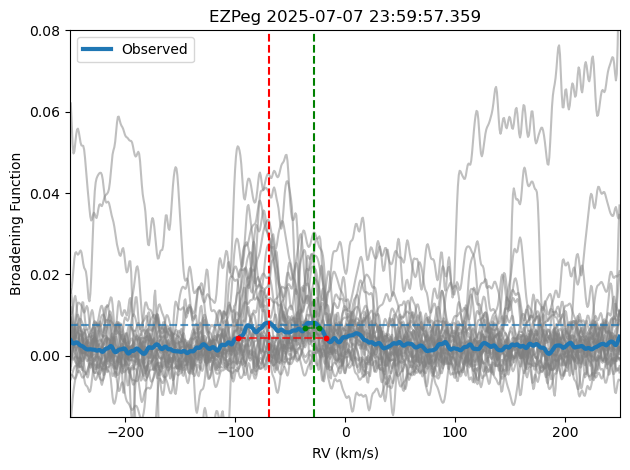

SB2
Amps: [0.00814159 0.0081201 ]
Centers: [-69.44376387 -28.26199692]
Widths: [80.11267546 13.08516116]
p0: [0.009, -76.388, 44.062, 0.009, -29.675, 6.87, 0.0]
Vsini p0: [0.008955743610958746, -49.39512686572286, 44.06197150192535, 0.008729110177080258, -29.702386317413215, 6.869709610368079, 0.0]
  BVCORR: 25.105 km/s
  
       Results
  Primary RV (uncorrected): -49.4 + 17.34 - 23.43
  Primary RV (Barycenter Corrected): -24.29 + 17.34 - 23.43

  Secondary RV (uncorrected): -29.7 + 2.88 - 3.45
  Secondary RV (Barycenter Corrected): -4.6 + 2.88 - 3.45

  Primary vsini:    71.78 +/- inf km/s
  Secondary vsini:  -781.32 +/- inf km/s
  
(-24.294263276296117, 17.34114567214509, 23.431818630568202, 71.77908110035335, inf, -4.599873632915985, 2.879347914099416, 3.448813632344411, -781.319816988409, inf)


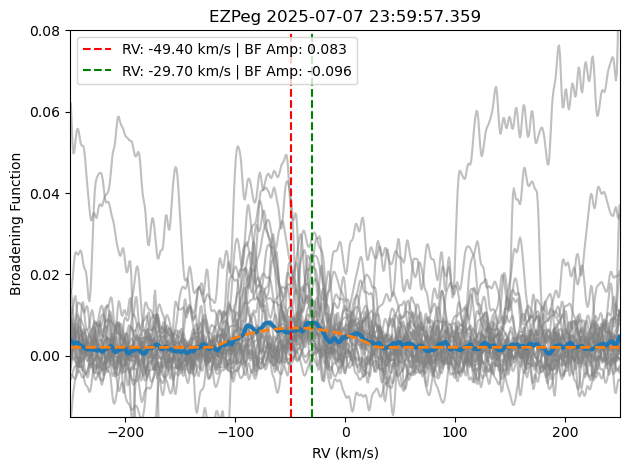


File 2
C:\Users\Jonah\Astro\Stars\DATA\stars2\EZPeg\EZPeg_2025-07-12_0_6300_4.5.p
Number of Spectral Orders: 28
BJD: 2460869.419626119
BVCORR 24.59
  Peak 1: center = -76.71 km/s, width = 11.38 km/s
  Peak 2: center = -28.26 km/s, width = 15.96 km/s


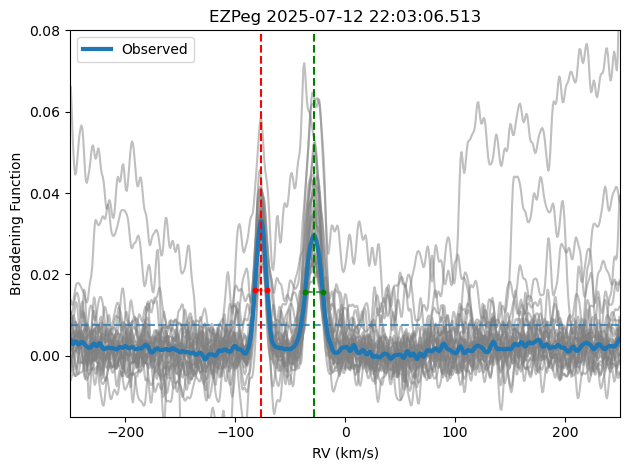

SB2
Amps: [0.03309303 0.02959444]
Centers: [-76.71113451 -28.26199692]
Widths: [11.38181147 15.95702742]
p0: [0.036, -84.382, 6.26, 0.032, -29.675, 8.377, 0.0]
Vsini p0: [0.03640233529764865, -76.5572377646468, 6.259996306045733, 0.03181401969503175, -28.490954821157025, 8.377439397861888, 0.0]
  BVCORR: 24.59 km/s
  
       Results
  Primary RV (uncorrected): -76.56 + 0.08 - 0.08
  Primary RV (Barycenter Corrected): -51.97 + 0.08 - 0.08

  Secondary RV (uncorrected): -28.49 + 0.12 - 0.13
  Secondary RV (Barycenter Corrected): -3.9 + 0.12 - 0.13

  Primary vsini:    11.18 +/- 0.12 km/s
  Secondary vsini:  6.65 +/- 0.13 km/s
  
(-51.97351725059327, 0.08124043413742754, 0.07690482136328569, 11.17621160583177, 0.11507744577252345, -3.903291746516728, 0.1213740064883666, 0.12615027847614613, 6.6452699545676746, 0.13369650362073554)


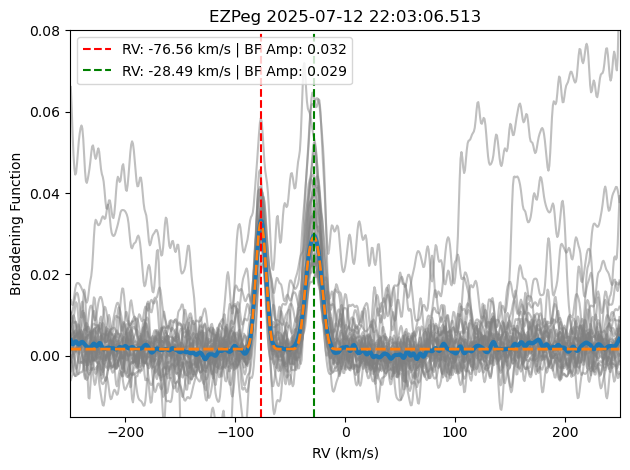


File 3
C:\Users\Jonah\Astro\Stars\DATA\stars2\EZPeg\EZPeg_2025-07-17_0_6300_4.5.p
Number of Spectral Orders: 28
BJD: 2460874.406075806
BVCORR 23.791
  Peak 1: center = -73.48 km/s, width = 15.61 km/s
  Peak 2: center = -29.88 km/s, width = 10.59 km/s


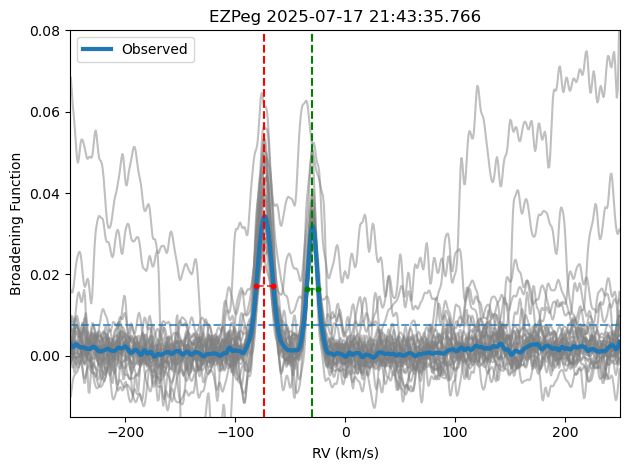

SB2
Amps: [0.03434715 0.03181644]
Centers: [-73.481192   -29.87696818]
Widths: [15.61135555 10.5863981 ]
p0: [0.038, -80.829, 8.586, 0.034, -31.371, 5.558, 0.0]
Vsini p0: [0.0377818636767557, -73.08549037815924, 8.586245552895473, 0.03420267088490141, -29.632775896908488, 5.557858999928739, 0.0]
  BVCORR: 23.791 km/s
  
       Results
  Primary RV (uncorrected): -73.09 + 0.08 - 0.08
  Primary RV (Barycenter Corrected): -49.3 + 0.08 - 0.08

  Secondary RV (uncorrected): -29.63 + 0.07 - 0.08
  Secondary RV (Barycenter Corrected): -5.84 + 0.07 - 0.08

  Primary vsini:    10.61 +/- 0.11 km/s
  Secondary vsini:  6.79 +/- 0.12 km/s
  
(-49.3002903137533, 0.08153070527914963, 0.07534638964511942, 10.60614525356111, 0.11477674797391274, -5.844127501731635, 0.07297733102783965, 0.07585123386777326, 6.794079500682989, 0.1206821152735161)


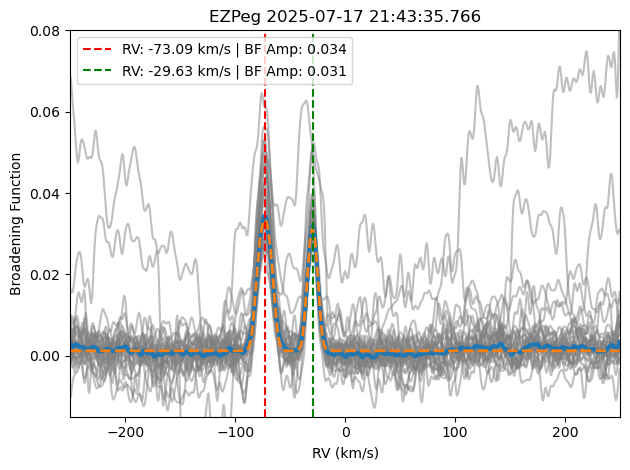


End
 ------------------------------------------------------------


In [83]:
SB1_indexes, SB2_indexes = [], []
results = []


p0s = []
for k in range(len(txtfiles)):
    print("File", k+1)
    filename = txtfiles[k]    #re-initialize a new filename
    filepath= os.path.join(path,filename)
    print(filepath)
    #read in the pickle and smooth the broadening function to instrumental resolution
    
    tar,tar_spec = pkl.load(open(filepath,'rb'))
    tar_spec = saph.bf.analysis(tar,tar_spec,R = R_coude)
    
    print(f'Number of Spectral Orders: {len(tar)}')

    ##############
    print(f"BJD: {BJD[k]}")
    print(f"BVCORR {BVCORR[k]}")
    time_title = Time(BJD[k], format='jd', scale='tdb')
    date_title = time_title.utc.iso
    
    #did not change much here, normal RV creation
    vel,bf,bf_sterr,bf_wstd = saph.bf.weight_combine(tar,tar_spec,vel_gt_lt=(+150,-150))
    ##############

    
    # plot everything
    #fig, ax = plt.subplots(figsize=(8,4))
    
    
    fig,ax = plt.subplots(1)
    '''
    for i in range(tar.size):

        print(f"Printing order {tar[i]}")
        ax.plot(tar_spec[tar[i]]['vel'],
                tar_spec[tar[i]]['bf_smooth'],
                color="grey", alpha=0.5)'''
    for key, spec in tar_spec.items():
        # Skip if missing BF products
        if 'vel' not in spec or 'bf_smooth' not in spec:
            print(f"Skipping {key}: missing BF")
            continue
        ax.plot(spec['vel'], spec['bf_smooth'], color="grey", alpha=0.5)

    ax.plot(vel, bf, label="Observed", lw=3)

    # define colors: largest peak = red, second = green
    center_colors = ['red', 'green']
    width_alphas  = [0.5, 0.5]  # widths will be same color but semi‐transparent





    ax.set_title(f"{star} {date_title}")
    ax.set_xlabel('RV (km/s)')
    ax.set_ylabel('Broadening Function')
    #ax.axvline(rvsmean, ls='--')
    plt.xlim(-250, 250)
    plt.ylim(-0.015, 0.08)
    #ax.axhline(0.01, ls = '--')
    ax.axhline(0.0075, ls = '--', alpha = 0.75)
    plt.legend()

    from scipy.signal import find_peaks, peak_widths
    peaks, props = find_peaks(bf, prominence=0.00001, distance = 25, height = 0.005) #These values work for most systems, may have to adjust
    num_peaks = len(peaks)

    
    # Isolate the two highest‐amplitude peaks
    peak_heights = bf[peaks]
    n_to_plot    = min(num_peaks, 2)
    top_idxs     = np.argsort(peak_heights)[::-1][:n_to_plot]
    two_peaks    = peaks[top_idxs]

    # get half‐max widths for those peaks
    widths, height_at_half, left_ips, right_ips = peak_widths(bf, two_peaks, rel_height=0.5)
    if num_peaks == 0:
        print("  no peaks found")
        plt.show()
        continue

    
        
    for i, peak in enumerate(two_peaks):
        c = center_colors[i]
        # 1) vertical line at the peak center
        ax.axvline(vel[peak], ls="--", color=c)
    
        # 2) left/right velocities for half‐max
        v_low  = np.interp(left_ips[i],  np.arange(len(vel)), vel)
        v_high = np.interp(right_ips[i], np.arange(len(vel)), vel)
    
        # 3) horizontal half‐max line
        ax.hlines(y=height_at_half[i],
                  xmin=v_low, xmax=v_high,
                  colors=c, linestyles='--', alpha=0.7)
    
        # 4a) tiny vertical bars at the two ends:
        #ax.plot([v_low, v_high],
        #        [height_at_half[i], height_at_half[i]],
        #        marker='|', linestyle='', markersize=10, color=c)
    
        # —OR— 4b) simple dots instead (uncomment to use):
        ax.scatter([v_low, v_high],
                    [height_at_half[i]]*2,
                    marker='o', s = 10, color=c, zorder = 10)
        print(f"  Peak {i+1}: center = {vel[peak]:.2f} km/s, width = {(v_high - v_low):.2f} km/s")

    plt.tight_layout()
    plt.show()
    plt.close()



    from Fit_SB1 import Run_SB1
    from Fit_SB2 import Run_SB2
    

    if num_peaks < 2 or Force_SB1 == True or widths[1] < 5:
        print("SB1")
        SB1_indexes.append(k)

        idx = np.arange(len(vel))
        left_vels  = np.interp(left_ips,  idx, vel)
        right_vels = np.interp(right_ips, idx, vel)
        # now pull out the three vectors:
        peak_amps   = bf[two_peaks]               # amplitudes at the two peaks
        peak_rvs    = vel[two_peaks]              # RV centerlines
        peak_widths = right_vels - left_vels      # width (km/s)
        
        print("Amps:",   peak_amps)
        print("Centers:",peak_rvs)
        print("Widths:", peak_widths)

        if manual == True:
            p0 = guesses[k]
        else:
            p0 = [peak_amps[0]*1.1, peak_rvs[0]*1.1, peak_widths[0]*1.1/2,
              0.0]
        
        print(f"p0: {[round(x, 3) for x in p0]}")
        output = Run_SB1(tar,tar_spec, vel,bf,bf_sterr,bf_wstd, 
                filename, star, date_title, BVCORR[k], p0)
        results.append((BJD[k], *output))
        print([output])





    
    else:
        print("SB2")
        SB2_indexes.append(k)

        idx = np.arange(len(vel))
        left_vels  = np.interp(left_ips,  idx, vel)
        right_vels = np.interp(right_ips, idx, vel)
        # now pull out the three vectors:
        peak_amps   = bf[two_peaks]               # amplitudes at the two peaks
        peak_rvs    = vel[two_peaks]              # RV centerlines
        peak_widths = right_vels - left_vels      # width (km/s)
        
        print("Amps:",   peak_amps)
        print("Centers:",peak_rvs)
        print("Widths:", peak_widths)

        if manual == True:
            p0 = guesses[k]
        #elif k == len(txtfiles) - 1:
        #    p0 = [ 0.014269385896399384, -74.66480800670901, 13.186207343707627, 0.015669322856370602, 68.224514112524, 33.489414447793436, 0.0001]
        else:
            p0 = [peak_amps[0]*1.1, peak_rvs[0]*1.1, peak_widths[0]*1.1/2,
             peak_amps[1]*1.075, peak_rvs[1]*1.05, peak_widths[1]*1.05/2,
              0.0]
        print(f"p0: {[round(x, 3) for x in p0]}")
        output = Run_SB2(tar,tar_spec, vel,bf,bf_sterr,bf_wstd, 
                        filename, star, date_title, BVCORR[k], p0)
        results.append((BJD[k], *output))
        print(output)

    #if k == 2:
    #    plt.savefig(f"{star}_{k}", dpi = 300)
    
    plt.tight_layout()
    plt.show()

    p0s.append(p0)     




    
    print()

print("End\n" , "--"*30)


In [84]:
print("p0 guesses:")   #prints all p0 guesses for review, can copy this for redoing manual guessing per-iteration
for p0 in p0s:
    print(f"{[round(x, 3) for x in p0]},")

p0 guesses:
[0.009, -49.395, 44.062, 0.009, -29.702, 6.87, 0.0],
[0.036, -76.557, 6.26, 0.032, -28.491, 8.377, 0.0],
[0.038, -73.085, 8.586, 0.034, -29.633, 5.558, 0.0],


In [85]:
print("BJD | RV1 | RV1_hi | RV1_lo | Vsini1 | Vsini1_err | RV2 | RV2_hi | RV2_lo | Vsini2 | Vsini2_err")
print("--"*45)


for i, tup in enumerate(results):
    formatted = ", ".join(f"{x:.4f}" for x in tup)
    if i < len(results) - 1:
        print(f"[{formatted}],")
    else:
        print(f"[{formatted}]")
#star = 'UCAC22884271'

BJD | RV1 | RV1_hi | RV1_lo | Vsini1 | Vsini1_err | RV2 | RV2_hi | RV2_lo | Vsini2 | Vsini2_err
------------------------------------------------------------------------------------------
[2460864.5008, -24.2943, 17.3411, 23.4318, 71.7791, inf, -4.5999, 2.8793, 3.4488, -781.3198, inf],
[2460869.4196, -51.9735, 0.0812, 0.0769, 11.1762, 0.1151, -3.9033, 0.1214, 0.1262, 6.6453, 0.1337],
[2460874.4061, -49.3003, 0.0815, 0.0753, 10.6061, 0.1148, -5.8441, 0.0730, 0.0759, 6.7941, 0.1207]


Primary
  Semi-Amplitude  : 13.840 km/s
  Mean            : -41.856 km/s
  STD             : 12.466 km/s
Primary Error Bars
  RV1_hi max      : 17.341 km/s
  RV1_hi mean     : 5.835 km/s
  RV1_lo max      : 23.432 km/s
  RV1_lo mean     : 7.861 km/s

Vsini1
  Mean            : 31.187
  Error mean      : inf
  Error max       : inf

Secondary
  Semi-Amplitude  : 0.970 km/s
  Mean            : -4.782 km/s
  STD             : 0.803 km/s
Secondary Error Bars
  RV2_hi max      : 2.879 km/s
  RV2_hi mean     : 1.025 km/s
  RV2_lo max      : 3.449 km/s
  RV2_lo mean     : 1.217 km/s

Vsini2
  Mean            : -255.960
  Error mean      : inf
  Error max       : inf



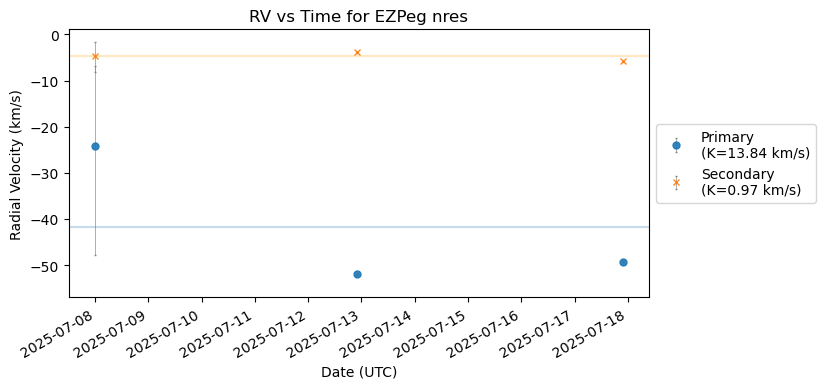

Number of files used: 3


In [86]:

#re-import in case we want to manually run results, for example:
#results = np.array([
#        [RV data format from {starname}_RV.txt],
#        [RV data format from {starname}_RV.txt],
#])

#Also, see example at the bottom of this file for UCAC2 28842571


import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time


#=========================================================
#RV, Vsini stats and plot for this star

# setup array/data tables
data     = np.array(results)
bjd      = data[:,0]
rv1      = data[:,1]
rv1_hi   = data[:,2]
rv1_lo   = data[:,3]
vsini1   = data[:,4]
vsini1_er= data[:,5]
rv2      = data[:,6]
rv2_hi   = data[:,7]
rv2_lo   = data[:,8]
vsini2   = data[:,9]
vsini2_er= data[:,10]

# PRIMARY RV stats
primary_amp    = (np.nanmax(rv1) - np.nanmin(rv1)) / 2
primary_mean   = np.nanmean(rv1)
primary_std    = np.nanstd(rv1)
rv1_hi_max     = np.nanmax(rv1_hi)
rv1_hi_mean    = np.nanmean(rv1_hi)
rv1_lo_max     = np.nanmax(rv1_lo)
rv1_lo_mean    = np.nanmean(rv1_lo)

print(f"""Primary
  Semi-Amplitude  : {primary_amp:.3f} km/s
  Mean            : {primary_mean:.3f} km/s
  STD             : {primary_std:.3f} km/s
Primary Error Bars
  RV1_hi max      : {rv1_hi_max:.3f} km/s
  RV1_hi mean     : {rv1_hi_mean:.3f} km/s
  RV1_lo max      : {rv1_lo_max:.3f} km/s
  RV1_lo mean     : {rv1_lo_mean:.3f} km/s
""")

# Vsini1 stats
vs1_mean      = np.nanmean(vsini1)
vs1_err_mean  = np.nanmean(vsini1_er)
vs1_err_max   = np.nanmax(vsini1_er)
print(f"""Vsini1
  Mean            : {vs1_mean:.3f}
  Error mean      : {vs1_err_mean:.3f}
  Error max       : {vs1_err_max:.3f}
""")

# Mask for valid secondary points
mask2 = ~np.isnan(rv2)

# Convert BJD → datetime
t     = Time(bjd, format='jd', scale='tdb')
dates = t.to_datetime()

fig, ax = plt.subplots(figsize=(7,4))

# Plot primary
ax.errorbar(dates, rv1,
            yerr=[rv1_lo, rv1_hi],
            fmt='o',
            label=f"Primary\n(K={primary_amp:.2f} km/s)",
            ecolor='grey', capsize=1, elinewidth=0.5,
            ms=5, alpha=0.9)

# Plot + compute secondary if we have any real points
if mask2.any():
    rv2_v      = rv2[mask2]
    rv2_lo_v   = rv2_lo[mask2]
    rv2_hi_v   = rv2_hi[mask2]
    dates_v    = dates[mask2]

    secondary_amp   = (np.nanmax(rv2_v) - np.nanmin(rv2_v)) / 2
    secondary_mean  = np.nanmean(rv2_v)
    secondary_std   = np.nanstd(rv2_v)
    rv2_hi_max      = np.nanmax(rv2_hi_v)
    rv2_hi_mean     = np.nanmean(rv2_hi_v)
    rv2_lo_max      = np.nanmax(rv2_lo_v)
    rv2_lo_mean     = np.nanmean(rv2_lo_v)

    print(f"""Secondary
  Semi-Amplitude  : {secondary_amp:.3f} km/s
  Mean            : {secondary_mean:.3f} km/s
  STD             : {secondary_std:.3f} km/s
Secondary Error Bars
  RV2_hi max      : {rv2_hi_max:.3f} km/s
  RV2_hi mean     : {rv2_hi_mean:.3f} km/s
  RV2_lo max      : {rv2_lo_max:.3f} km/s
  RV2_lo mean     : {rv2_lo_mean:.3f} km/s
""")

    # Vsini2 stats
    vs2 = vsini2[mask2]
    vs2_er = vsini2_er[mask2]
    vs2_mean     = np.nanmean(vs2)
    vs2_err_mean = np.nanmean(vs2_er)
    vs2_err_max  = np.nanmax(vs2_er)
    print(f"""Vsini2
  Mean            : {vs2_mean:.3f}
  Error mean      : {vs2_err_mean:.3f}
  Error max       : {vs2_err_max:.3f}
""")

    ax.errorbar(dates_v, rv2_v,
                yerr=[rv2_lo_v, rv2_hi_v],
                fmt='x',
                label=f"Secondary\n(K={secondary_amp:.2f} km/s)",
                ecolor='grey', capsize=1, elinewidth=0.5,
                ms=5, alpha=0.9)
    ax.axhline(secondary_mean, alpha=0.25, color='orange')
else:
    print("Secondary RV2 is all NaN; skipping its stats, Vsini2, and plot.")

# primary mean line
ax.axhline(primary_mean, alpha=0.25)

# y‐axis padding
if mask2.any():
    y_min = min(np.nanmin(rv1), np.nanmin(rv2)) - 5
    y_max = max(np.nanmax(rv1), np.nanmax(rv2)) + 5
else:
    y_min = np.min(rv1) - 5
    y_max = np.max(rv1) + 5
ax.set_ylim(y_min, y_max)

# date formatting
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Radial Velocity (km/s)')
ax.set_title(f'RV vs Time for {star} nres')

# legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.75, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

# ensure output folder & save
outdir = "PNGs_2"
os.makedirs(outdir, exist_ok=True)
plt.savefig(f"{outdir}/{star}.png", dpi=135, bbox_inches='tight')   #uncomment this to save the file
plt.show()
print(f"Number of files used: {len(data)}")

In [87]:
#Save data to .txt file formats:



# 0) number of data points
n_points = len(data)

# 1) Build the summary row
row = [
    star,
    n_points,                                    # number of points
    primary_amp,                                 # RV1_amp
    rv1_hi_max,                                  # rv1_hi
    rv1_lo_max,                                  # rv1_lo
    (secondary_amp  if mask2.any() else np.nan), # RV2_amp
    (rv2_hi_max     if mask2.any() else np.nan), # rv2_hi
    (rv2_lo_max     if mask2.any() else np.nan), # rv2_lo
]

# 2) Update the global summary file in array form
summary_dir  = "summary_nres"
summary_file = os.path.join(summary_dir, "results_summary.txt")
os.makedirs(summary_dir, exist_ok=True)

# Read existing lines (skip blanks and header)
entries = {}
if os.path.exists(summary_file):
    with open(summary_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("Star,"):
                continue
            # line looks like: ['StarName', N, ...],
            first = line.split(",", 2)[0]           # "['StarName'"
            key   = first.lstrip("[").strip().strip("'\"")
            entries[key] = line.rstrip(",")

# Build this star's line
sec_amp_str = f"{secondary_amp:.3f}" if mask2.any() else "nan"
sec_hi_str  = f"{rv2_hi_max:.3f}"    if mask2.any() else "nan"
sec_lo_str  = f"{rv2_lo_max:.3f}"    if mask2.any() else "nan"

row_str = "['%s', %d, %.3f, %.3f, %.3f, %s, %s, %s]," % (
    star,
    n_points,
    primary_amp,
    rv1_hi_max,
    rv1_lo_max,
    sec_amp_str,
    sec_hi_str,
    sec_lo_str
)
entries[star] = row_str

# Write back sorted by star name, with header
with open(summary_file, "w") as f:
    f.write("Star, N, RV1_amp, rv1_hi, rv1_lo, RV2_amp, rv2_hi, rv2_lo\n")
    for name in sorted(entries):
        f.write(entries[name] + "\n")


# 3) Write the detailed per-star file
star_dir = os.path.join("starstxt4_nres", star)
os.makedirs(star_dir, exist_ok=True)
star_file = os.path.join(star_dir, f"{star}.txt")
star_data = os.path.join(star_dir, f"{star}_RVs.txt")

with open(star_file, "w") as f:
    f.write(f"Star: {star}\n")
    f.write(f"Data length: {n_points}\n\n")

    # Primary
    f.write("Primary\n")
    f.write(f"  Amplitude       : {primary_amp:.3f} km/s\n")
    f.write(f"  Mean            : {primary_mean:.3f} km/s\n")
    f.write(f"  STD             : {primary_std:.3f} km/s\n")
    f.write("Primary Error Bars\n")
    f.write(f"  RV1_hi max      : {rv1_hi_max:.3f} km/s\n")
    f.write(f"  RV1_hi mean     : {rv1_hi_mean:.3f} km/s\n")
    f.write(f"  RV1_lo max      : {rv1_lo_max:.3f} km/s\n")
    f.write(f"  RV1_lo mean     : {rv1_lo_mean:.3f} km/s\n\n")

    # Vsini1
    f.write("Vsini1\n")
    f.write(f"  Mean            : {vs1_mean:.3f}\n")
    f.write(f"  Error mean      : {vs1_err_mean:.3f}\n")
    f.write(f"  Error max       : {vs1_err_max:.3f}\n\n")


    
    # Secondary (if present)
    if mask2.any():
        f.write("Secondary\n")
        f.write(f"  Amplitude       : {secondary_amp:.3f} km/s\n")
        f.write(f"  Mean            : {secondary_mean:.3f} km/s\n")
        f.write(f"  STD             : {secondary_std:.3f} km/s\n")
        f.write("Secondary Error Bars\n")
        f.write(f"  RV2_hi max      : {rv2_hi_max:.3f} km/s\n")
        f.write(f"  RV2_hi mean     : {rv2_hi_mean:.3f} km/s\n")
        f.write(f"  RV2_lo max      : {rv2_lo_max:.3f} km/s\n")
        f.write(f"  RV2_lo mean     : {rv2_lo_mean:.3f} km/s\n\n")
        f.write("Vsini2\n")
        f.write(f"  Mean            : {vs2_mean:.3f}\n")
        f.write(f"  Error mean      : {vs2_err_mean:.3f}\n")
        f.write(f"  Error max       : {vs2_err_max:.3f}\n")
    else:
        f.write("Secondary RV2 is all NaN; skipping its stats and Vsini2.\n\n")
        
    f.write("\nInitial Fit Parameters (p0):\n")
    for p0 in p0s:
        f.write(f"{[round(x, 3) for x in p0]}\n")



with open(star_data, "w") as f:
    for j in range(n_points):
            bjds     = bjd[j]
            rv1s      = rv1[j]
            rv1_his   = rv1_hi[j]
            rv1_los   = rv1_lo[j]
    
            if mask2.any():
                rv2s     = rv2[j]
                rv2_his  = rv2_hi[j]
                rv2_los  = rv2_lo[j]
                line = f"[{bjds:.5f}, {rv1s:.3f}, {rv1_his:.3f}, {rv1_los:.3f}, {rv2s:.3f}, {rv2_his:.3f}, {rv2_los:.3f}]"
            else:
                line = f"[{bjds:.5f}, {rv1s:.3f}, {rv1_his:.3f}, {rv1_los:.3f}, nan, nan, nan]"

            if j < n_points-1:
                f.write(line + ',\n')

            else:
                f.write(line + '\n')



# manually eliminate vsini data if necessary
bad_indices = [] #modify this by index

for k in bad_indices:
    vsini1[k]    = np.nan
    vsini1_er[k] = np.nan
    if mask2.any():
        vsini2[k]    = np.nan
        vsini2_er[k] = np.nan



# New file: per-epoch Vsini data
vsini_file = os.path.join(star_dir, f"{star}_vsini.txt")

with open(vsini_file, "w") as f:
    for j in range(n_points):
        bjds   = bjd[j]
        vs1    = vsini1[j]
        vs1_er = vsini1_er[j]

        # Apply cutoff for primary
        if vs1_er > 5:
            vs1    = np.nan
            vs1_er = np.nan

        if mask2.any():
            vs2    = vsini2[j]
            vs2_er = vsini2_er[j]

            # Apply cutoff for secondary
            if vs2_er > 5:
                vs2    = np.nan
                vs2_er = np.nan

            line = (
                f"[{bjds:.5f}, "
                f"{vs1:.3f}, {vs1_er:.3f}, "
                f"{vs2:.3f}, {vs2_er:.3f}]"
            )
        else:
            line = (
                f"[{bjds:.5f}, "
                f"{vs1:.3f}, {vs1_er:.3f}, "
                f"nan, nan]"
            )

        if j < n_points - 1:
            f.write(line + ",\n")
        else:
            f.write(line + "\n")

print("========== End of Line =========")

Done


In [702]:
#Manual results adjustments

results = [
[2459067.9228, 1.7543, 0.0695, 0.0671, 8.6124, 0.1027, -40.6678, 0.0989, 0.0797, 7.8151, 0.0789],
[2459095.8570, 39.9079, 0.0857, 0.0952, 7.8699, 0.0824, -78.4719, 0.0701, 0.0614, 8.4064, 0.0910],
[2459095.8756, 39.9900, 0.0889, 0.0882, 8.0521, np.nan, -78.5009, 0.0532, 0.0593, -0.0043, np.nan],
[2459095.8942, 40.0078, 0.0900, 0.0854, 8.3663, 0.0982, -78.4602, 0.0478, 0.0473, 7.7398, 0.0633],
[2459108.7816, -16.3875, 0.7907, 18.5443, 7.8354, np.nan, 14.5437, 0.9062, 17.7271, 0.0631, np.nan],
[2459108.8008, -35.0916, 12.3175, 0.0825, 8.0105, 0.0639, -3.1322, 7.8485, 0.1059, 7.2037, 0.0854],
[2459119.7984, -51.2200, 0.0935, 0.0880, 8.6194, 0.0642, 12.2430, 0.0718, 0.0784, 7.4499, 0.1003],
[2459119.8170, -51.1326, 0.0909, 0.0788, 8.4906, 0.1901, 12.2563, 0.0682, 0.0602, 0.1289, 533514.2332],
[2459119.8357, -51.0890, 0.0830, 0.0708, 7.5252, 1204265.9514, 12.2673, 0.0733, 0.0931, 0.3079, 0.2523],
[2459121.7752, -46.2364, 0.1040, 0.1221, 8.4845, 0.0958, 6.6792, 0.0772, 0.0736, 7.2751, 0.0727],
[2459121.7937, 6.7237, 0.0829, 0.0892, 8.6546, 0.1284, -46.0700, 0.0904, 0.1186, 7.0430, 0.0994],
[2459121.8125, 6.6914, 0.0798, 0.0909, 8.6059, 1591643.5713, -46.0196, 0.1162, 0.1092, 0.4013, 0.1693],
[2459122.8305, -40.4786, 0.0829, 0.0807, 0.1945, 919637.1632, 1.8984, 0.0551, 0.0522, 0.2392, 1468262.3134],
[2459122.8512, 1.0896, 0.1362, 0.1170, 8.3489, 0.1015, -40.5417, 0.1824, 0.1534, 7.3713, 0.1675],
[2459122.8734, -40.1044, 0.0877, 0.0928, 8.1991, 0.0830, 1.7327, 0.0724, 0.0653, 7.3824, 0.1015],
[2459123.8009, -15.4522, 0.6137, 5.9529, 6.3253, 1923631.1952, 11.4557, 0.6001, 7.7655, 0.4102, 0.2585],
[2459123.8195, -15.3954, 0.6367, 5.7852, 8.0240, 0.0679, 11.3285, 0.4547, 6.5179, 6.5076, 0.0751],
[2459123.8381, -15.0156, 0.5222, 4.4648, 6.4502, 2401974.6218, 11.5851, 0.4234, 6.2783, 0.4570, 0.2546],
[2459124.8030, -19.2934, 0.0785, 0.0724, 11.2697, 0.0760, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459124.8227, -19.2935, 0.1001, 0.0931, 10.8481, 0.0837, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459124.8413, -19.3516, 0.0753, 0.0781, 10.4838, 0.0602, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459174.6834, -27.1278, 0.0682, 0.0707, 8.8877, 0.1983, -11.0049, 0.0848, 0.0872, 0.2702, 1045756.3653],
[2459174.7043, -27.1435, 0.0665, 0.0597, 10.5609, 0.1349, -10.8599, 0.0793, 0.0813, 0.4029, 585814.5243],
[2459174.7244, -27.4205, 0.0583, 0.0590, 9.0498, 0.1602, -10.8339, 0.0615, 0.0669, 0.3893, 954004.3598],
[2459175.6527, -30.7817, 0.1365, 0.1112, 8.0480, np.nan, -6.2118, 0.1816, 0.1294, -0.0264, np.nan],
[2459175.6711, -31.0169, 0.1259, 0.1022, 0.4544, 2004788.1763, -6.3709, 0.1770, 0.1227, 7.5350, 0.3208],
[2459175.6896, -31.3187, 0.1527, 0.1094, 0.4198, 1629143.6102, -6.4406, 0.2508, 0.1651, 7.5049, 0.2932],
[2459187.6342, -50.5727, 0.2106, 0.2108, 0.2120, 863831.9351, 13.1717, 0.1446, 0.1551, -7.2928, 0.3300],
[2459187.6529, 13.1248, 0.1391, 0.1345, 8.5213, 0.0750, -50.6065, 0.2075, 0.1982, 7.4366, 0.1291],
[2459187.6714, 13.0292, 0.1325, 0.1462, 8.5234, 1637551.6367, -50.4906, 0.1532, 0.1722, 0.5119, 0.2254],
[2459188.6361, -48.3751, 0.0846, 0.0923, 0.4474, 2501451.4716, 11.0379, 0.0909, 0.0958, 0.4811, 2345496.2292],
[2459188.6546, -48.4029, 0.0777, 0.0579, 7.7629, 908425.2109, 10.8411, 0.1036, 0.0938, 0.6214, 0.3059],
[2459452.9127, -48.9548, 0.0844, 0.0676, 8.0859, 0.1949, 10.1398, 0.1114, 0.1061, 0.4351, 2541674.0596],
[2459453.8904, -50.5279, 0.0857, 0.0898, 8.3627, 0.0680, 11.4890, 0.0828, 0.0918, 7.8815, 0.1064],
[2459490.8374, 13.8370, 0.0705, 0.0622, 8.6215, 0.0627, -52.5073, 0.0931, 0.0854, 7.6702, 0.0719]
]

In [708]:
results = np.array(results)
np.mean(results[:,2]), np.mean(results[:,3])

(0.5086542857142856, 1.0746571428571425)